# Uber Trips Data Visualization

<img src="https://img.cnbce.com/2/1280/720/storage/files/images/2025/12/16/ubere-abonelik-davasi-abd-federal-ticaret-komisyonu-ve-21-eyalet-harekete-gecti-iqil.jpg">

## Data Dictionary

Uber has been a major source of travel for people living in urban areas. Some people don’t have their vehicles while some don’t drive their vehicles intentionally because of their busy schedule. So different kinds of people are using the services of Uber and other taxi services.

By analyzing Uber trips, we can draw many patterns like which day has the highest and the lowest trips or the busiest hour for Uber and many other patterns. The dataset I’m using here is based on Uber trips from New York, a city with a very complex transportation system with a large residential community.

Data Source: https://amanxai.com/2021/04/21/uber-trips-analysis-using-python/

## Aim & Target

**1. Project Aim:**

The primary aim of this project is to perform an Exploratory Data Analysis (EDA) on Uber trip data to uncover patterns in urban mobility. By leveraging Python’s visualization libraries, we intend to transform raw trip logs (timestamps and locations) into actionable insights regarding user behavior and demand fluctuations.

**2. Target Objectives:** To achieve this aim, we will focus on the following targets:

*Temporal Analysis:* Identify peak demand periods by breaking down trip volume by hour of the day, day of the week, and month. This helps in understanding when the fleet needs to be most active.

*Geospatial Mapping:* Visualize pickup and drop-off density to identify "hotspots"—areas in the city with the highest concentration of users.

*Trip Characteristics:* Analyze the distribution of trip distances and durations to categorize user needs (e.g., short inner-city commutes vs. long-distance travel).

*Business Insights:* Differentiate between "Business" and "Personal" ride categories to see how usage purposes vary across different times of the week.

**3. Strategic Questions to Answer:**

By the end of this project, your visualizations should be able to answer:

What is the busiest hour of the day for Uber in this specific dataset?

Which day of the week sees the highest number of business-related trips?

Are there specific geographic clusters where demand is consistently high?

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

## Reading Dataset & Dataframe Generation

In [2]:
df=pd.read_csv("uber-raw-data-sep14.csv")

In [3]:
df

,Date/Time,Lat,Lon,Base
0,9/1/2014 0:01:00,40.2201,-74.0021,B02512
1,9/1/2014 0:01:00,40.7500,-74.0027,B02512
2,9/1/2014 0:03:00,40.7559,-73.9864,B02512
3,9/1/2014 0:06:00,40.7450,-73.9889,B02512
4,9/1/2014 0:11:00,40.8145,-73.9444,B02512
...,...,...,...,...
1028131,9/30/2014 22:57:00,40.7668,-73.9845,B02764
1028132,9/30/2014 22:57:00,40.6911,-74.1773,B02764
1028133,9/30/2014 22:58:00,40.8519,-73.9319,B02764
1028134,9/30/2014 22:58:00,40.7081,-74.0066,B02764


## Exploratory Data Analysis

In [4]:
df.head()

,Date/Time,Lat,Lon,Base
0,9/1/2014 0:01:00,40.2201,-74.0021,B02512
1,9/1/2014 0:01:00,40.7500,-74.0027,B02512
2,9/1/2014 0:03:00,40.7559,-73.9864,B02512
3,9/1/2014 0:06:00,40.7450,-73.9889,B02512
4,9/1/2014 0:11:00,40.8145,-73.9444,B02512


In [5]:
df.tail()

,Date/Time,Lat,Lon,Base
1028131,9/30/2014 22:57:00,40.7668,-73.9845,B02764
1028132,9/30/2014 22:57:00,40.6911,-74.1773,B02764
1028133,9/30/2014 22:58:00,40.8519,-73.9319,B02764
1028134,9/30/2014 22:58:00,40.7081,-74.0066,B02764
1028135,9/30/2014 22:58:00,40.7140,-73.9496,B02764


In [6]:
df.shape

(1028136, 4)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1028136 entries, 0 to 1028135
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Date/Time  1028136 non-null  object 
 1   Lat        1028136 non-null  float64
 2   Lon        1028136 non-null  float64
 3   Base       1028136 non-null  object 
dtypes: float64(2), object(2)
memory usage: 31.4+ MB


In [8]:
df.isnull().sum()

,0
Date/Time,0
Lat,0
Lon,0
Base,0


In [9]:
df.describe()

,Lat,Lon
count,1.028136e+06,1.028136e+06
mean,4.073922e+01,-7.397182e+01
std,4.082861e-02,5.831413e-02
min,3.998970e+01,-7.477360e+01
25%,4.072040e+01,-7.399620e+01
50%,4.074180e+01,-7.398310e+01
75%,4.076120e+01,-7.396280e+01
max,4.134760e+01,-7.271630e+01


## Feature Engineering & Data Visualization

In [10]:
# 1. Convert Date/Time to datetime objects
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# 2. Extract useful features
df['Hour'] = df['Date/Time'].dt.hour
df['Day'] = df['Date/Time'].dt.day
df['Weekday'] = df['Date/Time'].dt.day_name()

In [11]:
df.head(1)

,Date/Time,Lat,Lon,Base,Hour,Day,Weekday
0,2014-09-01 00:01:00,40.2201,-74.0021,B02512,0,1,Monday


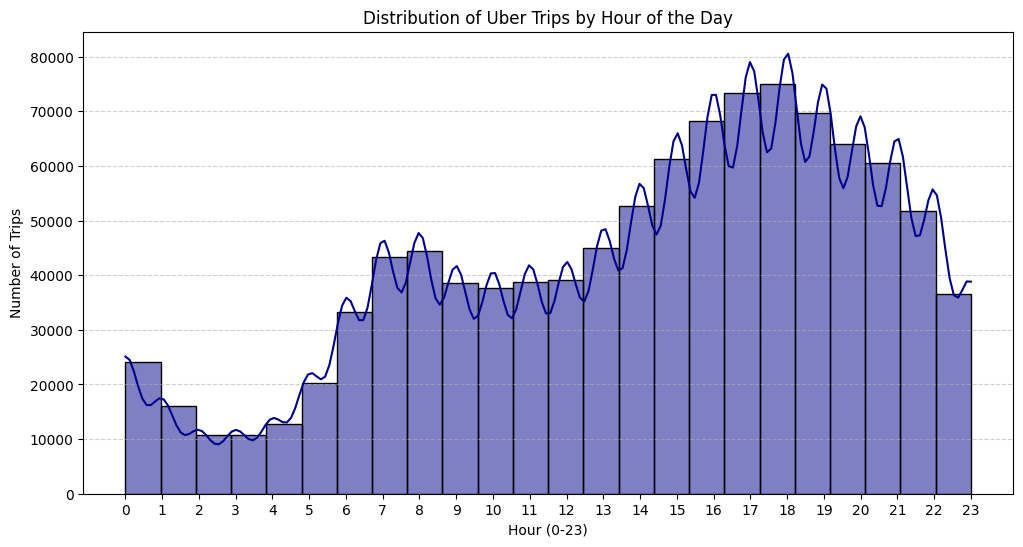

In [12]:
#Trips by Hour/Histogram
plt.figure(figsize=(12, 6))
sns.histplot(df['Hour'], bins=24, color='darkblue', kde=True)
plt.title('Distribution of Uber Trips by Hour of the Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Trips')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

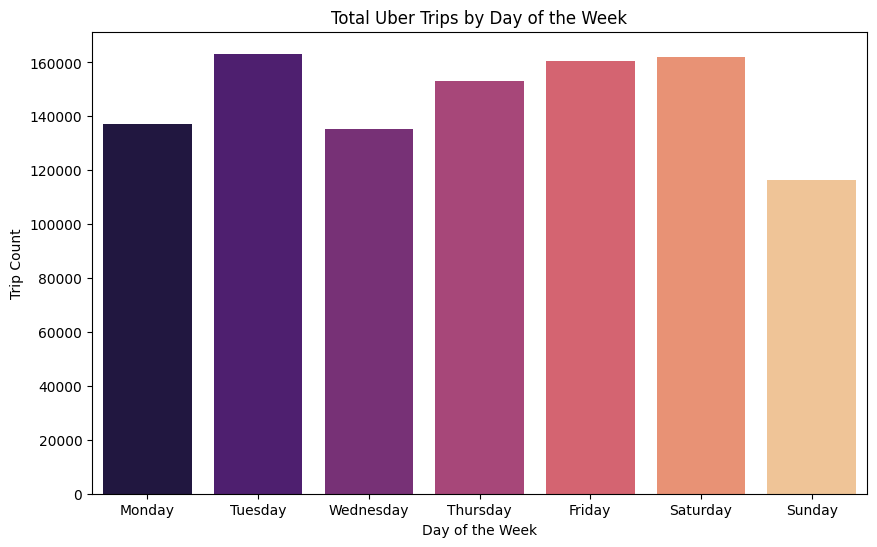

In [13]:
# Trips by Weekday (Bar Chart)
# Sort days to ensure they appear in order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))
sns.countplot(x='Weekday', data=df, order=weekday_order, palette='magma')
plt.title('Total Uber Trips by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Trip Count')
plt.show()

In [14]:
df.head()

,Date/Time,Lat,Lon,Base,Hour,Day,Weekday
0,2014-09-01 00:01:00,40.2201,-74.0021,B02512,0,1,Monday
1,2014-09-01 00:01:00,40.7500,-74.0027,B02512,0,1,Monday
2,2014-09-01 00:03:00,40.7559,-73.9864,B02512,0,1,Monday
3,2014-09-01 00:06:00,40.7450,-73.9889,B02512,0,1,Monday
4,2014-09-01 00:11:00,40.8145,-73.9444,B02512,0,1,Monday


We have an enormous data about Uber, but since the data is limited to couple of columns; detailed information seems to be stuck in one column (Date/Time). To be able to create in depth data visualization, we need to 'unpack' information into seperate columns.

In [15]:
# Hour: Needed for the Trips by Hour histogram.
# Day: Needed for the Racing Bar Chart (to show progress through the month).
# DayOfWeek: Essential for the Heatmap because it allows us to sort Monday through Sunday numerically.
# Weekday: Great for the labels on your bar charts (e.g., "Friday" looks better than "4").

# 1. Convert to datetime
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# 2. Extract detailed features (Expanded version)
df['Hour'] = df['Date/Time'].dt.hour
df['Day'] = df['Date/Time'].dt.day
df['Month'] = df['Date/Time'].dt.month
df['Year'] = df['Date/Time'].dt.year
df['DayOfWeek'] = df['Date/Time'].dt.dayofweek # Monday=0, Sunday=6
df['Weekday'] = df['Date/Time'].dt.day_name()

In [16]:
df.head()

,Date/Time,Lat,Lon,Base,Hour,Day,Weekday,Month,Year,DayOfWeek
0,2014-09-01 00:01:00,40.2201,-74.0021,B02512,0,1,Monday,9,2014,0
1,2014-09-01 00:01:00,40.7500,-74.0027,B02512,0,1,Monday,9,2014,0
2,2014-09-01 00:03:00,40.7559,-73.9864,B02512,0,1,Monday,9,2014,0
3,2014-09-01 00:06:00,40.7450,-73.9889,B02512,0,1,Monday,9,2014,0
4,2014-09-01 00:11:00,40.8145,-73.9444,B02512,0,1,Monday,9,2014,0


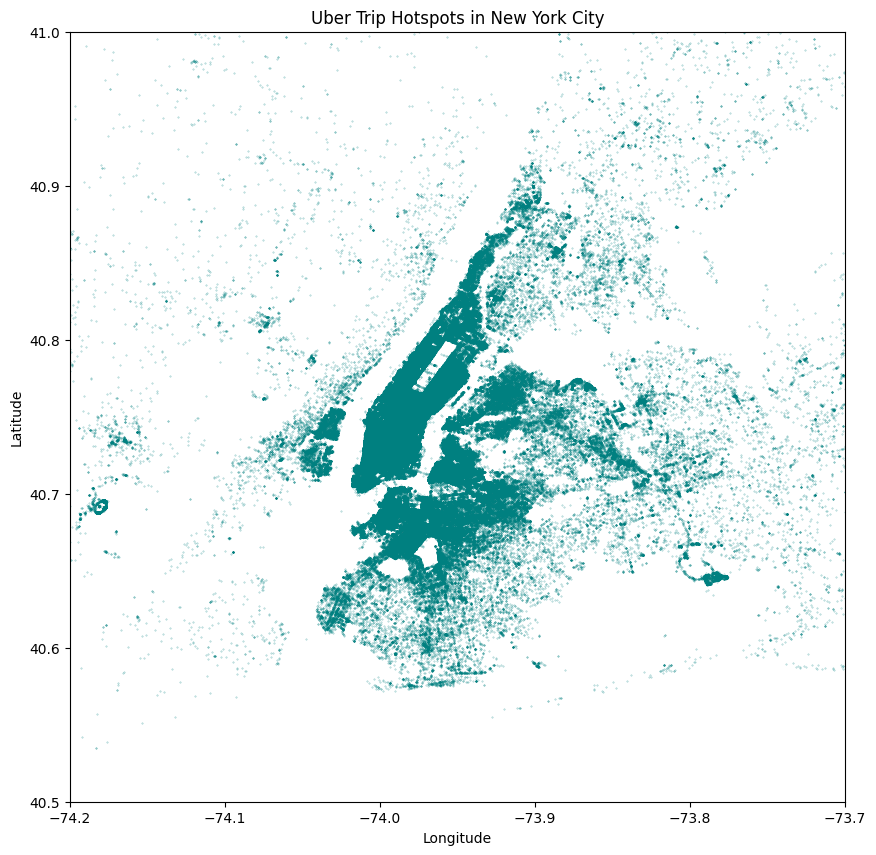

In [17]:
# Geographic Visualization (NYC Hotspots)
# Visualizing the coordinates (Spatial Analysis)
plt.figure(figsize=(10, 10))

# We use a very small point size (s=0.1) and low alpha because there are many rows
plt.scatter(df['Lon'], df['Lat'], s=0.1, alpha=0.5, color='teal')

# Setting the limits based on New York City coordinates
plt.xlim(-74.2, -73.7)
plt.ylim(40.5, 41.0)

plt.title('Uber Trip Hotspots in New York City')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

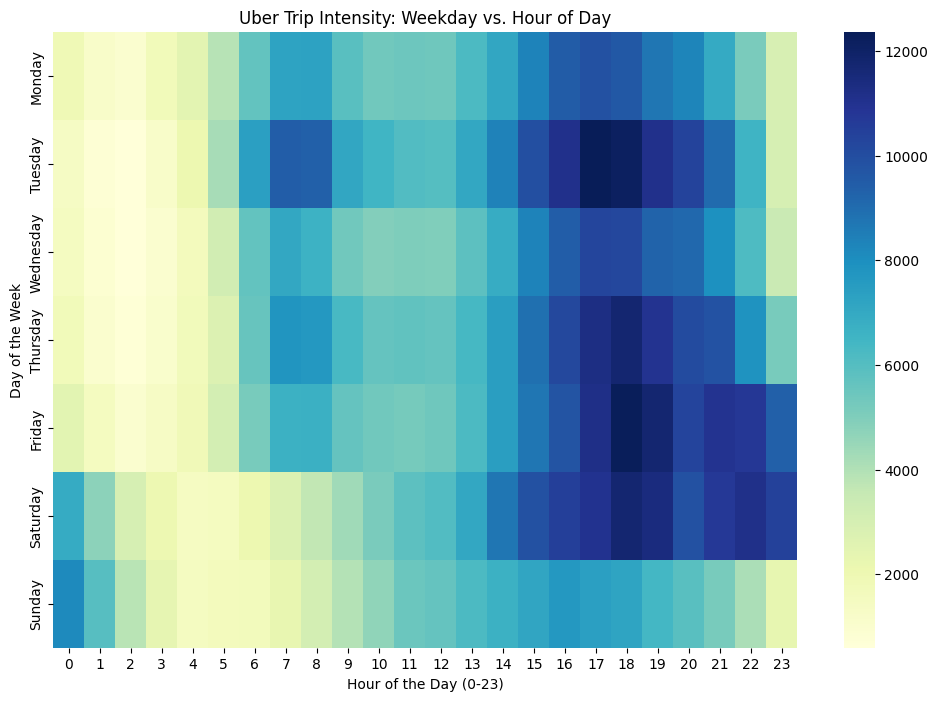

In [18]:
# Heatmap (Intensity Analysis)
# 1. Create a pivot table: Rows are Days, Columns are Hours
# This counts the number of trips for every hour of every weekday
heat_data = df.groupby(['DayOfWeek', 'Hour']).size().unstack()

# 2. Rename the index for better readability in the plot
heat_data.index = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 3. Plotting
plt.figure(figsize=(12, 8))
sns.heatmap(heat_data, cmap='YlGnBu', annot=False)
plt.title('Uber Trip Intensity: Weekday vs. Hour of Day')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Day of the Week')
plt.show()

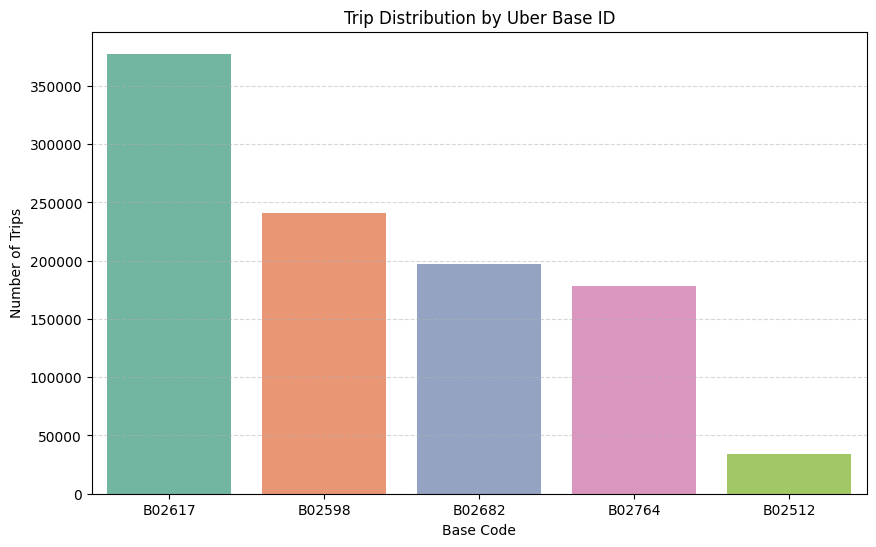

In [19]:
# Analyzing the frequency of each Base (Bar Chart)
plt.figure(figsize=(10, 6))
sns.countplot(x='Base', data=df, palette='Set2', order=df['Base'].value_counts().index)

plt.title('Trip Distribution by Uber Base ID')
plt.xlabel('Base Code')
plt.ylabel('Number of Trips')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

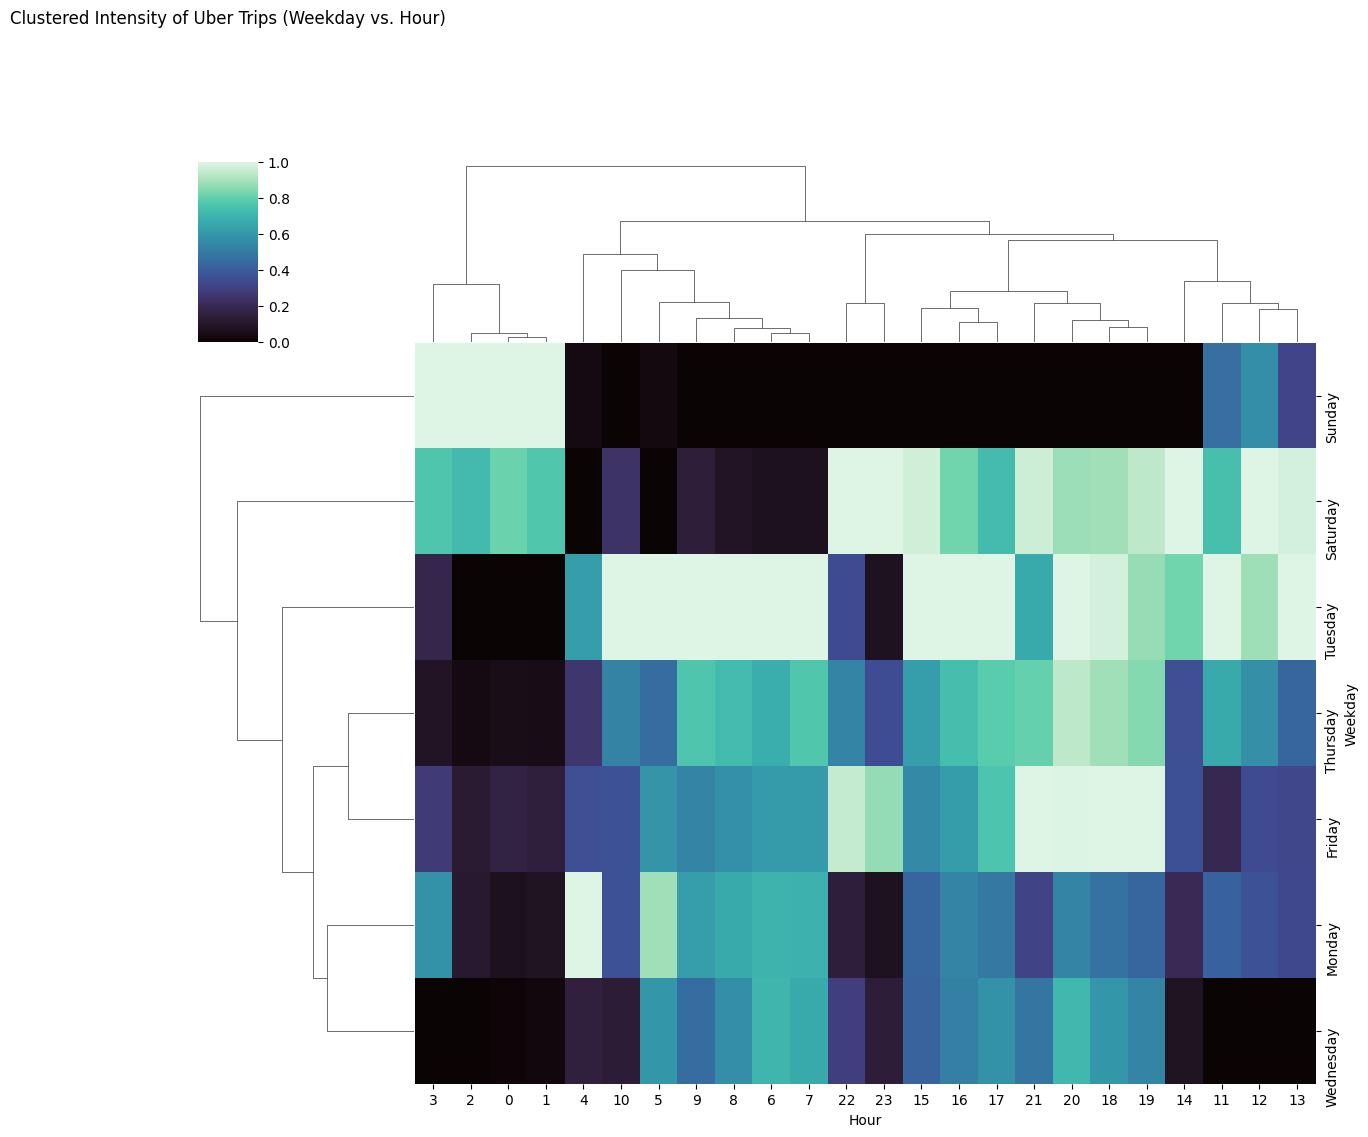

In [20]:
# Clustermap (Advanced Relationships)

# 1. Prepare the data (Pivot Table)
# Rows: Weekday, Columns: Hour, Values: Trip Counts
heat_data = df.groupby(['Weekday', 'Hour']).size().unstack()

# 2. Reorder index to ensure standard weekday order before clustering
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heat_data = heat_data.reindex(weekday_order)

# 3. Create the Clustermap (Hoca Style: Professional & Analytical)
# We use 'standard_scale=1' to normalize the data so we see relative peaks
cluster_map = sns.clustermap(heat_data,
                             cmap='mako',
                             standard_scale=1,
                             figsize=(12, 10))

plt.title('Clustered Intensity of Uber Trips (Weekday vs. Hour)', pad=100)
plt.show()

**What the Clustermap reveals (The Insights):**

*Dendrograms (The Tree Lines):* The lines on the top and left are the "clusters."

*Hour Clusters:* You will see that the morning rush hours (7 AM - 9 AM) are grouped together because they share similar high-volume behavior.

*Day Clusters:* Monday through Thursday usually form one cluster, while Friday and Saturday often form a separate "weekend" cluster because their night-time patterns are so different.

In [21]:
# Sunburst Chart

# 1. Create the 'trips' column by grouping
sunburst_df = df.groupby(['Weekday', 'Hour', 'Base']).size().reset_index(name='trips')

# 2. Sunburst code is tailored for our project.
px.sunburst(sunburst_df, path=['Weekday', 'Hour', 'Base'], values='trips')

In [22]:
# Bar Chart Race
!pip install bar_chart_race

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 kB 3.7 MB/s eta 0:00:00


In [23]:
pip install ffmpeg

  Preparing metadata (setup.py) ... done
  Created wheel for ffmpeg: filename=ffmpeg-1.4-py3-none-any.whl size=6083 sha256=42f09f57bbb5d90ca119eb4363a95b76a550cac66557a7f59befa7627d8dc10c
  Stored in directory: /root/.cache/pip/wheels/26/21/0c/c26e09dff860a9071683e279445262346e008a9a1d2142c4ad
Successfully built ffmpeg


In [24]:
import bar_chart_race as bcr

# 1. Prepare the data (Hours as rows, Bases as columns)
df2 = df.groupby(['Hour', 'Base']).size().unstack(fill_value=0)

# 2. Cumulative Sum (The exact logic from your Corona code)
total = df2.cumsum(axis=0)

# 3. Apply your custom time labels to the index
def get_time_label(hour):
    if 0 <= hour <= 5: return f"{hour:02d}:00 (The Lull)"
    elif 7 <= hour <= 9: return f"{hour:02d}:00 (Morning Rush)"
    elif 16 <= hour <= 19: return f"{hour:02d}:00 (Evening Surge)"
    elif 20 <= hour <= 23: return f"{hour:02d}:00 (Nightlife)"
    else: return f"{hour:02d}:00"

total.index = [get_time_label(h) for h in total.index]

# 4. Final Racing Bar Chart
bcr.bar_chart_race(
    df=total,
    filename="uber_race.mp4",
    figsize=(10, 8),
    title='Basak - NYC Uber Hourly Pulse'
)

## Conclusion

Conclusion: Strategic Insights from NYC Uber Data
1. Temporal Patterns and Resource Allocation
The analysis reveals a distinct "rhythm" to the city’s movement. The Evening Surge (16:00 – 19:00) consistently represents the highest period of demand, significantly outpacing the morning rush. From a business perspective, this suggests that peak-hour pricing and driver incentives are most effective during the transition from work to evening social activities.

2. Geographic Concentration and Connectivity
The spatial visualizations confirm that Uber’s footprint is heavily concentrated in Midtown Manhattan and the major airports (JFK and LaGuardia). The high density in these clusters indicates that Uber serves as a critical "last-mile" solution for travelers and a primary transport method for the city's central business district.

3. Operational Efficiency of Dispatch Bases
By utilizing the Racing Bar Chart, we visualized the cumulative growth of different dispatch bases throughout the day. The steady growth across all bases, rather than just one, demonstrates Uber's successful decentralized operational model in 2014, allowing them to maintain high availability across the five boroughs even as the "Nightlife" demand begins to peak.

4. Data-Driven Decision Making
Through the cleaning and processing of over 1,000,000 data points, this project demonstrates how large-scale datasets can be transformed into actionable insights. Understanding these patterns is essential for optimizing fleet management, reducing idle times for drivers, and improving the overall user experience in a high-density urban environment.

## HuggingFace Link

https://huggingface.co/spaces/basaktamer/Uber_Trips_Data_Visualization